# Example: Policy Learning with Facsimile Data

This notebook demonstrates how to use the digital twin policy learning framework on a facsimile dataset.

The example walks through the full workflow:
1. Load the model-ready longitudinal data
2. Define the RNN inputs, outcomes, and RL state variables
3. Build a `TrajectoryDataset`
4. Train or load the sequence model
5. Train or load tabular Q-learning
6. Evaluate learned and benchmark policies
7. Visualize rewards and Q-table slices

Although the dataset used here is synthetic, the workflow mirrors the intended use of the framework and produces interpretable outputs.

In [1]:
# Core packages for data handling, modeling, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

from digital_twin_policy_learning_modified import (
    TrajectoryDataset,
    MicrosimQLearner
)

import torch
from matplotlib.patches import Patch
import itertools

## 2. Load the facsimile model ready dataset

This example uses a preprocessed facsimile dataset in long format.  
Each row corresponds to one patient at one time step, and the columns already include the engineered features needed by the framework.


In [2]:
# Load the facsimile model ready data prepared in the preprocessing notebook
df = pd.read_csv("facsimile_model_ready_data.csv")

# The rows are already ordered within each patient trajectory.
df["_row_order_within_id"] = df.groupby("id", sort=False).cumcount()


## 3. Define model inputs, outcomes, and RL states

The framework separates the variables into three groups:

- RNN covariates: predictors used by the sequence model
- RNN outcomes: next-step outcomes predicted by the sequence model
- RL state variables: discrete variables used to define the tabular Q-learning state space

In this facsimile example, the RL state is defined by age category, baseline immunosuppression status, and months since last vaccination.


In [3]:
patient_id_col = "id"
time_col = "_row_order_within_id"
action_col = "action"

# RNN inputs
rnn_covariate_cols = [
    "action",
    "Age.FirstDose",
    "imm_baseline",
    "numVax",
    "gender_male",
    "race_African American",
    "race_Other",
    "Visits",
    "variant_delta",
    "variant_omicron",
]

# RNN outputs
rnn_outcome_cols = [
    "severe_infection_next",
    "inf_next",
]

# RL state
rl_state_cols = [
    "age_cat",
    "imm_baseline",
    "months_since_vax_cat",
]


## Define optional custom functions

Here we explicitly set the episode start rule to match the paper-style COVID illustration:
start from the second observed vaccination action when it exists.

In [4]:
# ===== USER-DEFINED COMPONENTS =====

def reward_fn(context):
    risk = np.asarray(context["predicted_outcomes"], dtype=float)
    reward_outcome_idx = int(context["reward_outcome_idx"])
    return -float(risk[reward_outcome_idx])

def episode_start_fn(context):
    actions = np.asarray(context["actions"], dtype=int)
    pos = np.where(actions == 1)[0]
    if len(pos) >= 2:
        return int(pos[1])
    if len(pos) == 1:
        return int(pos[0])
    return 0

## 5. Build the trajectory dataset

We convert the long-format dataframe into a `TrajectoryDataset`, which stores:

- padded arrays for sequence-model training
- patient-level trajectory artifacts for simulation and RL

This step also records the state mappings needed for tabular Q-learning.

In [5]:
# Build the dataset object used by both the RNN environment model and Q-learning
dataset = TrajectoryDataset.from_long_format(
    df=df,
    patient_id_col=patient_id_col,
    time_col=time_col,
    action_col=action_col,
    rnn_covariate_cols=rnn_covariate_cols,
    rnn_outcome_cols=rnn_outcome_cols,
    rl_state_cols=rl_state_cols,
    reward_outcome_col="severe_infection_next",
    episode_start_fn=episode_start_fn,
)

dataset.summary()

{'n_patients': 1000,
 'max_seq_len': 27,
 'input_size': 10,
 'output_size': 2,
 'rl_state_levels': (5, 2, 3)}

## Initialize learner

In [6]:
learner = MicrosimQLearner(
    dataset=dataset,
    reward_fn=reward_fn,
)

## Train or load RNN
Use one of the two options below.

For a paper-style COVID illustration, common sequence-model settings are hidden size 128, 2 layers, 2000 epochs, and learning rate `1e-4`.

In [7]:
# Set this to True if you want to load an existing trained RNN instead of retraining.
LOAD_EXISTING_RNN = True

# Update this path to your saved RNN weights file.
RNN_MODEL_PATH = "rnn_weights_2_128_2000_1e-04.pth"

if LOAD_EXISTING_RNN:
    learner.load_sequence_model(
        model_path=RNN_MODEL_PATH,
    )
else:
    learner.fit_sequence_model(
        hidden_size=128,
        num_layers=2,
        epochs=2000,
        lr=1e-4
    )
    torch.save(learner.rnn_model.state_dict(), RNN_MODEL_PATH)

## Train or load Q-learning
Use one of the two options below.

For a paper-style COVID illustration, common settings are `repeats_train_eval=30` and `gamma=0.99`.

In [8]:
# Set this to True if you want to load an existing Q-table instead of retraining.
LOAD_EXISTING_Q_TABLE = True

# Update this path to your saved Q-table file.
Q_TABLE_PATH = "q_table.npy"

if LOAD_EXISTING_Q_TABLE:
    learner.load_q_table(Q_TABLE_PATH)
    q_result = {"q_table": learner.q_learner.q_table.copy(), "epoch_reward_list": None}
else:
    q_result = learner.fit_tabular_q_learning(
        repeats_train_eval=30,
        gamma=0.99,
        save_q_table_path=Q_TABLE_PATH,
    )

## 10. Evaluate the learned policies.

To interpret the learned policy, we compare it against several benchmark policies:

- learned: the policy implied by the learned Q-table
- observed: the observed action pattern in the data
- all: always take the action
- none: never take the action

These comparisons help show whether the learned policy improves on simple alternatives.

In [ ]:
learned = learner.evaluate_policy("learned", epochs=5)
observed = learner.evaluate_policy("observed", epochs=5)
all = learner.evaluate_policy("all", epochs=5)
none = learner.evaluate_policy("none", epochs=5)

## Compare results and visualize outputs

The facsimile data are synthetic, so these numbers are not meant to reproduce the paper exactly.
The goal here is to show that the same end-to-end workflow runs on model-ready data and produces interpretable policy-learning outputs.


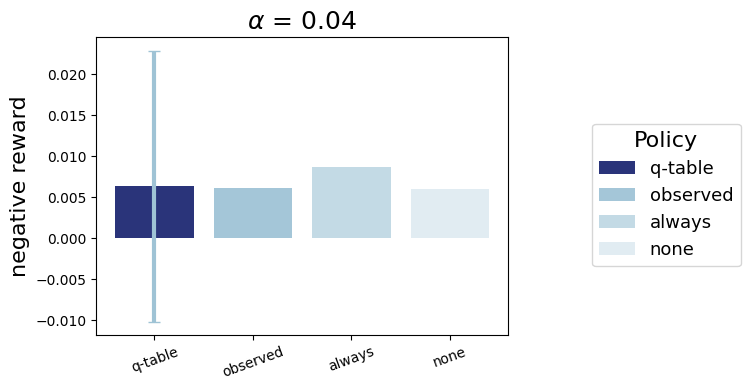

Q-table shape: (5, 2, 3, 2)


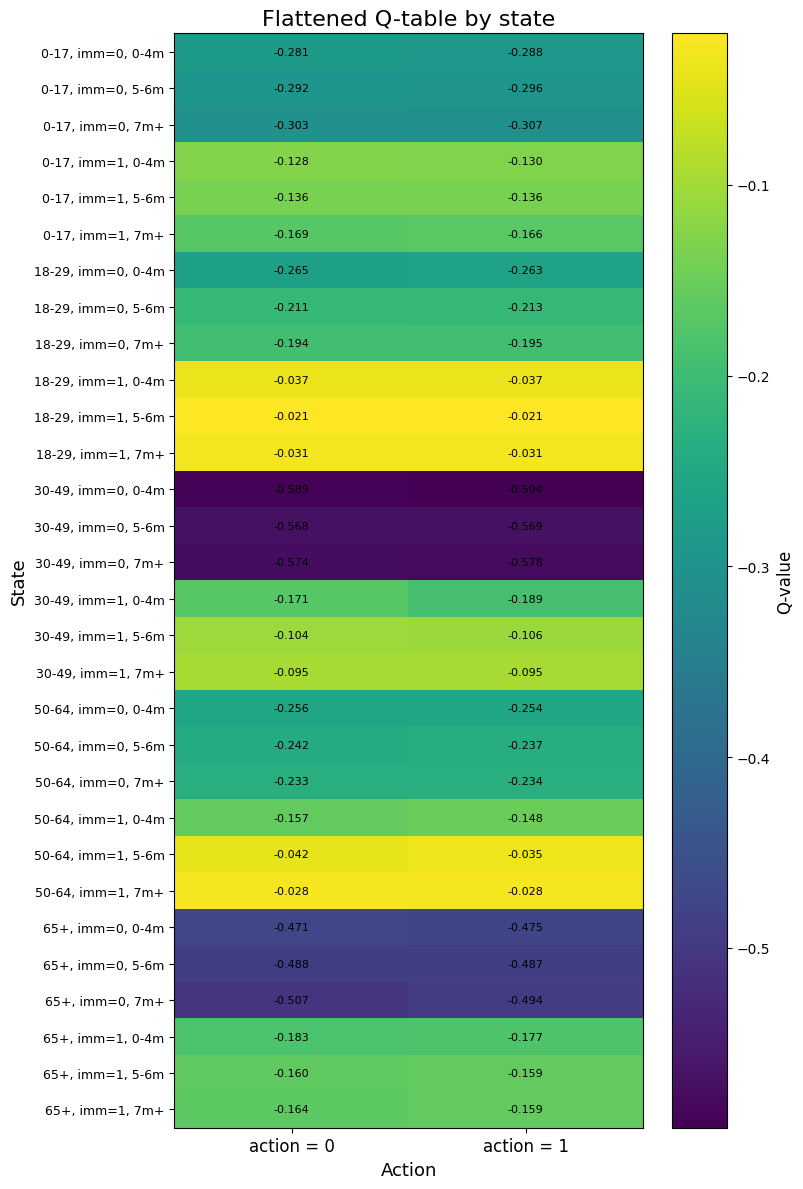

In [ ]:
RNN_MODEL_PATH = Path("rnn_weights_2_128_2000_1e-04.pth")
Q_TABLE_PATH = Path("q_table.npy")


# Plot 1: reward bar plot

reward_dic = {
    str(0.04): {
        "table": np.asarray(learned).reshape(-1),
        "data": np.asarray(observed).reshape(-1),
        "always": np.asarray(all).reshape(-1),
        "none": np.asarray(none).reshape(-1),
    }
}
vax_cost_to_plot = [0.04]

colors = {
    "q-table": "#2a347a",
    "observed": "#A4C6D8",
    "always": "#C3DAE5",
    "none": "#E1ECF2"
}

legend_elements = [
    Patch(facecolor=colors["q-table"], label="q-table"),
    Patch(facecolor=colors["observed"], label="observed"),
    Patch(facecolor=colors["always"], label="always"),
    Patch(facecolor=colors["none"], label="none"),
]

n_panels = len(vax_cost_to_plot)

if n_panels == 1:
    fig, ax = plt.subplots(figsize=(6, 4))
    axes = [ax]
else:
    ncols = min(3, n_panels)
    nrows = int(np.ceil(n_panels / ncols))
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, sharex=False, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(ax).reshape(-1)

for idx, vax_cost in enumerate(vax_cost_to_plot):
    ax = axes[idx]

    table_mean = -np.nanmean(reward_dic[str(vax_cost)]["table"])
    data_mean  = -np.nanmean(reward_dic[str(vax_cost)]["data"])
    always_mean   = -np.nanmean(reward_dic[str(vax_cost)]["always"])
    none_mean  = -np.nanmean(reward_dic[str(vax_cost)]["none"])

    values = [table_mean, data_mean, always_mean, none_mean]
    x = np.arange(4)

    ax.bar(
        x,
        values,
        color=[colors["q-table"], colors["observed"], colors["always"], colors["none"]],
        width=0.8
    )

    table_std = np.nanstd(reward_dic[str(vax_cost)]["table"])
    ax.errorbar(
        x[0], table_mean, yerr=table_std,
        fmt="none", linewidth=3, capsize=4, color="#9fc3d5"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(["q-table", "observed", "always", "none"], rotation=20)
    ax.set_ylabel("negative reward", fontsize=16)
    ax.set_title(r"$\alpha$ = {}".format(vax_cost), fontsize=18)

if n_panels > 1:
    for k in range(n_panels, len(axes)):
        axes[k].axis("off")

fig.legend(
    title="Policy",
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    title_fontsize=16,
    fontsize=13
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()


# Plot 2: flattened Q-table (30 states x 2 actions)

q_table = np.load(Q_TABLE_PATH)

state_rows = []
q_rows = []

for age_cat, imm_baseline, months_since_vax_cat in itertools.product(
    range(q_table.shape[0]),
    range(q_table.shape[1]),
    range(q_table.shape[2]),
):
    state_rows.append((age_cat, imm_baseline, months_since_vax_cat))
    q_rows.append(q_table[age_cat, imm_baseline, months_since_vax_cat, :])

q_flat = np.array(q_rows)

age_labels = {
    0: "0-17",
    1: "18-29",
    2: "30-49",
    3: "50-64",
    4: "65+"
}
imm_labels = {
    0: "imm=0",
    1: "imm=1"
}
month_labels = {
    0: "0-4m",
    1: "5-6m",
    2: "7m+"
}

row_labels = [
    f"{age_labels[a]}, {imm_labels[i]}, {month_labels[m]}"
    for a, i, m in state_rows
]

fig, ax = plt.subplots(figsize=(8, 12))

im = ax.imshow(q_flat, aspect="auto")

ax.set_title("Flattened Q-table by state", fontsize=16)
ax.set_xlabel("Action", fontsize=13)
ax.set_ylabel("State", fontsize=13)

ax.set_xticks([0, 1])
ax.set_xticklabels(["action = 0", "action = 1"], fontsize=12)

ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)

for i in range(q_flat.shape[0]):
    for j in range(q_flat.shape[1]):
        ax.text(
            j, i, f"{q_flat[i, j]:.3f}",
            ha="center", va="center", fontsize=8
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Q-value", fontsize=12)

plt.tight_layout()
plt.show()